# DSP Concepts: Interactive Demos

All demos are **live** — use the sliders and dropdowns to explore how each parameter affects the signal in real time.

Run the setup cell first, then run each section independently.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, Audio

from src.modulation.modulation import generate_baseband_tone, am_modulate, fm_modulate
from src.modulation.am_demod import envelope_demod, coherent_demod
from src.modulation.fm_demod import fm_demod
from src.signal.noise import add_awgn
from src.analysis.metrics import compute_snr_db

%matplotlib inline
plt.rcParams['figure.figsize'] = (13, 4)

## 1. Sampling & Aliasing

Move the **tone frequency** slider above `fs/2` (the Nyquist limit) and watch the peak jump to the wrong frequency — that's aliasing.
The red dashed line marks the Nyquist frequency.

In [ ]:
def plot_aliasing(tone_hz, fs):
    # ── Signal Processing ────────────────────────────────────────────────────
    n = int(fs * 1.0)
    t = np.arange(n) / fs
    x = np.cos(2 * np.pi * tone_hz * t)
    freqs = np.fft.fftshift(np.fft.fftfreq(n, 1/fs))
    mag = 20 * np.log10(np.maximum(np.abs(np.fft.fftshift(np.fft.fft(x))), 1e-12))

    # ── Visualization ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(t[:200], x[:200])
    axes[0].set_title(f'Time domain  (tone={tone_hz} Hz, fs={fs} Hz)')
    axes[0].set_xlabel('Time (s)')
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(freqs, mag, linewidth=1)
    axes[1].axvline(fs/2, color='red', linestyle='--', alpha=0.7, label='Nyquist')
    axes[1].axvline(-fs/2, color='red', linestyle='--', alpha=0.7)
    axes[1].set_title('Spectrum')
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Magnitude (dB)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(
    plot_aliasing,
    tone_hz=widgets.IntSlider(value=800, min=100, max=3000, step=50, description='Tone (Hz)', style={'description_width':'initial'}),
    fs=widgets.IntSlider(value=2000, min=500, max=8000, step=100, description='Sample rate (Hz)', style={'description_width':'initial'}),
);

interactive(children=(IntSlider(value=800, description='Tone (Hz)', max=3000, min=100, step=50, style=SliderSt…

### What the parameters control

**Tone frequency** sets the frequency of the input sinusoid $x(t) = \cos(2\pi f_0 t)$. As you increase it toward the Nyquist limit $f_s/2$, the spectral peak moves right. Push it above $f_s/2$ and aliasing occurs — the sampler cannot distinguish $f_0$ from $f_0 - f_s$, so the peak folds back and appears at $f_s - f_0$ instead. The time-domain waveform looks like a lower-frequency tone even though the original signal was higher.

**Sample rate $f_s$** controls where the Nyquist limit falls (red dashed line at $f_s/2$). Increasing $f_s$ pushes the limit higher, allowing higher-frequency tones to be represented without aliasing. The Nyquist–Shannon theorem states that faithful reconstruction requires $f_s > 2 f_0$. Violating this condition produces aliasing distortion that cannot be recovered.

## 2. Spectral Leakage & Windowing

Switch window types and adjust the tone frequency. Rectangular has the most leakage; Hann and Hamming trade main-lobe width for reduced leakage.

In [ ]:
def plot_windowing(tone_hz, window):
    # ── Signal Processing ────────────────────────────────────────────────────
    fs = 8000.0
    n = 512                      # short frame: taper + cycles both visible in time plot
    t = np.arange(n) / fs
    x = np.cos(2 * np.pi * tone_hz * t)
    w = {'Rectangular': np.ones(n), 'Hann': np.hanning(n), 'Hamming': np.hamming(n), 'Blackman': np.blackman(n)}[window]
    freqs = np.fft.fftshift(np.fft.fftfreq(n, 1/fs))
    mag = 20 * np.log10(np.maximum(np.abs(np.fft.fftshift(np.fft.fft(x * w))), 1e-12))

    # ── Visualization ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Left: windowed signal — dashed red envelope shows the window shape applied
    axes[0].plot(t * 1000, x, alpha=0.2, color='steelblue', linewidth=0.8, label='Raw signal')
    axes[0].plot(t * 1000, x * w, color='darkorange', linewidth=0.8, label='Windowed')
    axes[0].plot(t * 1000,  w, 'r--', linewidth=1.5, label='Window shape')
    axes[0].plot(t * 1000, -w, 'r--', linewidth=1.5)
    axes[0].set_ylim(-1.15, 1.15)
    axes[0].set_title(f'Time Domain — {window} window')
    axes[0].set_xlabel('Time (ms)')
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Right: spectrum — leakage comparison (full Nyquist span, log magnitude)
    axes[1].plot(freqs, mag, linewidth=1)
    axes[1].set_xlim(0, fs / 2)
    axes[1].set_ylim(mag.max() - 120, mag.max() + 10)
    axes[1].axvline(tone_hz, color='green', linestyle=':', alpha=0.6, label=f'Tone {tone_hz} Hz')
    axes[1].set_title(f'Spectrum — {window}')
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Magnitude (dB)')
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

interact(
    plot_windowing,
    tone_hz=widgets.IntSlider(value=1200, min=200, max=3800, step=50, description='Tone (Hz)', style={'description_width':'initial'}),
    window=widgets.Dropdown(options=['Rectangular','Hann','Hamming','Blackman'], value='Rectangular', description='Window'),
);

interactive(children=(IntSlider(value=1200, description='Tone (Hz)', max=3800, min=200, step=50, style=SliderS…

### What the parameters control

**Tone frequency** determines whether the sinusoid fits an integer number of cycles in the analysis window. When it does (coherent sampling), the DFT sees a periodic signal and produces a sharp spectral line. When it does not, the DFT sees a discontinuity at the window edges — energy spreads into neighbouring bins, known as **spectral leakage**.

**Window function** tapers the signal to zero at both ends before computing the DFT, reducing the effective discontinuity:

| Window | Main lobe width | Side lobe level | Tradeoff |
|--------|----------------|-----------------|----------|
| Rectangular | Narrowest | Highest (−13 dB) | Best frequency resolution, worst leakage |
| Hann | Wider | −31 dB | Good general purpose |
| Hamming | Wider | −41 dB | Better side lobe suppression than Hann |
| Blackman | Widest | −57 dB | Best leakage rejection, worst resolution |

Wider main lobe means two close frequencies are harder to resolve. Lower side lobes mean a weak signal near a strong one is less likely to be masked.

## 3. AM Modulation

Adjust the **modulation index** μ: below 1 = normal AM, above 1 = overmodulation (envelope crosses zero, distortion).
Watch how the sidebands in the spectrum move as you change message frequency.

In [4]:
def plot_am_mod(mod_index, carrier_hz, msg_hz):
    # ── Signal Processing ────────────────────────────────────────────────────
    fs = 8000.0
    baseband = generate_baseband_tone(fs, duration_s=0.05, freq_hz=msg_hz)
    am = am_modulate(baseband, carrier_hz=carrier_hz, modulation_index=mod_index)
    envelope = 1 + mod_index * baseband.m / np.max(np.abs(baseband.m))
    n = am.size
    freqs = np.fft.fftshift(np.fft.fftfreq(n, 1/fs))
    mag = 20 * np.log10(np.maximum(np.abs(np.fft.fftshift(np.fft.fft(am))), 1e-12))

    # ── Visualization ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(baseband.t * 1000, baseband.m, label='Message', alpha=0.7)
    axes[0].plot(baseband.t * 1000, am, label='AM signal', alpha=0.8)
    axes[0].plot(baseband.t * 1000, envelope, 'r--', alpha=0.6, label='Envelope')
    axes[0].set_title(f'AM Time Domain  (μ={mod_index:.2f})')
    axes[0].set_xlabel('Time (ms)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(freqs, mag, linewidth=1)
    axes[1].set_xlim(carrier_hz - 300, carrier_hz + 300)
    axes[1].set_title('AM Spectrum — Carrier + Sidebands')
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Magnitude (dB)')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(
    plot_am_mod,
    mod_index=widgets.FloatSlider(value=0.6, min=0.0, max=1.5, step=0.05, description='Mod index μ', style={'description_width':'initial'}),
    carrier_hz=widgets.IntSlider(value=1000, min=500, max=3000, step=50, description='Carrier (Hz)', style={'description_width':'initial'}),
    msg_hz=widgets.IntSlider(value=50, min=10, max=400, step=10, description='Message (Hz)', style={'description_width':'initial'}),
);

interactive(children=(FloatSlider(value=0.6, description='Mod index μ', max=1.5, step=0.05, style=SliderStyle(…

### What the parameters control

$$x_{AM}(t) = [1 + \mu \cdot m(t)] \cos(2\pi f_c t)$$

**Modulation index μ** controls how much the message modulates the carrier amplitude. At μ = 0 the envelope is flat (unmodulated carrier). At μ = 1 the envelope just touches zero — full modulation. Above μ = 1 the envelope crosses zero, causing **overmodulation**: the carrier phase inverts, sidebands distort, and a simple envelope detector cannot recover the message correctly. In the spectrum, higher μ raises the sideband peaks relative to the carrier.

**Carrier frequency $f_c$** shifts the entire AM spectrum left or right. In the spectrum view you can see the carrier spike flanked by two sidebands at $f_c \pm f_m$. Changing the carrier doesn't affect modulation quality — only which part of the RF spectrum the signal occupies.

**Message frequency $f_m$** controls the spacing between the carrier and sidebands — sidebands appear at $f_c \pm f_m$. Higher message frequency pushes the sidebands further apart. The bandwidth of a single-tone AM signal is $2 f_m$.

## 4. FM Modulation

Increase **frequency deviation** `kf` and watch the FM spectrum widen (Carson's rule: BW ≈ 2(Δf + fm)).
Notice the amplitude envelope stays constant — unlike AM.

In [5]:
def plot_fm_mod(kf, carrier_hz, msg_hz):
    # ── Signal Processing ────────────────────────────────────────────────────
    fs = 8000.0
    baseband = generate_baseband_tone(fs, duration_s=0.05, freq_hz=msg_hz)
    fm = fm_modulate(baseband, carrier_hz=carrier_hz, kf=kf)
    n = fm.size
    freqs = np.fft.fftshift(np.fft.fftfreq(n, 1/fs))
    mag = 20 * np.log10(np.maximum(np.abs(np.fft.fftshift(np.fft.fft(fm))), 1e-12))

    # ── Visualization ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(baseband.t * 1000, baseband.m, label='Message', alpha=0.7)
    axes[0].plot(baseband.t * 1000, fm, label='FM signal', alpha=0.8)
    axes[0].set_title(f'FM Time Domain  (kf={kf})')
    axes[0].set_xlabel('Time (ms)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(freqs, mag, linewidth=1)
    axes[1].set_xlim(carrier_hz - 600, carrier_hz + 600)
    axes[1].set_title(f'FM Spectrum  (Carson BW ≈ {2*(kf+msg_hz):.0f} Hz)')
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Magnitude (dB)')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(
    plot_fm_mod,
    kf=widgets.IntSlider(value=50, min=5, max=300, step=5, description='Deviation kf', style={'description_width':'initial'}),
    carrier_hz=widgets.IntSlider(value=1000, min=500, max=3000, step=50, description='Carrier (Hz)', style={'description_width':'initial'}),
    msg_hz=widgets.IntSlider(value=50, min=10, max=400, step=10, description='Message (Hz)', style={'description_width':'initial'}),
);

interactive(children=(IntSlider(value=50, description='Deviation kf', max=300, min=5, step=5, style=SliderStyl…

### What the parameters control

$$x_{FM}(t) = \cos\!\left(2\pi f_c t + 2\pi k_f \int_0^t m(\tau)\,d\tau\right)$$

**Frequency deviation $k_f$** controls how much the instantaneous frequency swings away from the carrier in response to the message. Higher $k_f$ means a wider frequency swing and a wider spectrum. Carson's rule approximates the occupied bandwidth as $BW \approx 2(\Delta f + f_m)$ where $\Delta f = k_f \cdot A_m$ is the peak deviation — visible in the plot title. Unlike AM, the envelope stays constant regardless of $k_f$.

**Carrier frequency $f_c$** shifts the spectrum without affecting modulation — same role as in AM.

**Message frequency $f_m$** affects both the sideband spacing and, via Carson's rule, the total bandwidth. Higher $f_m$ at fixed $k_f$ widens the spectrum. The ratio $\beta = k_f / f_m$ is the **modulation index** for FM — high $\beta$ (high deviation, low message freq) produces many Bessel sidebands and a wide spectrum.

## 5. Noise & Demodulation Quality

Drag the **SNR slider** down and watch demodulation break. Toggle between AM and FM — FM holds up better at low SNR because information is in the phase, not the amplitude.

In [ ]:
def plot_noise_demod(snr_db, modulation):
    # ── Signal Processing / Demodulation ─────────────────────────────────────
    fs = 8000.0
    num_taps = 129
    group_delay = (num_taps - 1) // 2   # = 64 samples
    transient  = num_taps - 1            # = 128; first fully-settled output sample
    baseband = generate_baseband_tone(fs, duration_s=0.5, freq_hz=50.0)
    if modulation == "AM":
        sig = am_modulate(baseband, carrier_hz=1000.0, modulation_index=0.6)
        noisy = add_awgn(sig.astype(np.complex64), snr_db=snr_db)
        rec = coherent_demod(noisy, fs, carrier_hz=1000.0, lpf_cutoff_hz=200.0)
    else:
        sig = fm_modulate(baseband, carrier_hz=1000.0, kf=50.0)
        noisy = add_awgn(sig.astype(np.complex64), snr_db=snr_db)
        from scipy.signal import hilbert
        noisy_iq = hilbert(noisy.real).astype(np.complex64)
        rec = fm_demod(noisy_iq, fs, lpf_cutoff_hz=200.0)
        rec = rec - np.mean(rec)

    # Align recovered signal with original (compensate for filter group delay)
    start_ref = transient - group_delay   # = 64
    n = min(baseband.m.size - start_ref, rec.size - transient)
    ref = baseband.m[start_ref : start_ref + n]
    est = rec[transient : transient + n]
    rms_ref = np.sqrt(np.mean(ref ** 2))
    rms_est = np.sqrt(np.mean(est ** 2))
    if rms_est > 0:
        est = est * (rms_ref / rms_est)
    out_snr = compute_snr_db(ref, est)
    t_ms = np.arange(n) / fs * 1000

    # ── Visualization ────────────────────────────────────────────────────────
    plt.figure(figsize=(13, 4))
    plt.plot(t_ms, ref, label='Original', linewidth=2)
    plt.plot(t_ms, est, '--', label=f'Recovered  (output SNR = {out_snr:.1f} dB)', linewidth=1.5, alpha=0.8)
    plt.title(f'{modulation} Demodulation  —  Input SNR = {snr_db} dB')
    plt.xlabel('Time (ms)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(
    plot_noise_demod,
    snr_db=widgets.IntSlider(value=10, min=-20, max=30, step=2, description='Input SNR (dB)', style={'description_width':'initial'}),
    modulation=widgets.ToggleButtons(options=['AM', 'FM'], description='Modulation'),
);

interactive(children=(IntSlider(value=10, description='Input SNR (dB)', max=30, min=-20, step=2, style=SliderS…

## 6. Real Data: KiwiSDR AM (153 kHz)

Live AM demodulation from a real KiwiSDR recording. Adjust the **LPF cutoff** — the red line on the spectrum shows where audio is cut off.

In [7]:
from src.data_tools.data_loaders import load_kiwisdr_iq
kiwi_data = load_kiwisdr_iq('../data/am_153khz.wav', sample_rate=12000.0)
print(f'KiwiSDR: {kiwi_data.iq.size} samples @ {kiwi_data.sample_rate:.0f} Hz  ({kiwi_data.iq.size/kiwi_data.sample_rate:.1f} s)')

KiwiSDR: 60928 samples @ 12000 Hz  (5.1 s)


In [8]:
def plot_kiwi_am(lpf_hz):
    # ── Signal Processing ────────────────────────────────────────────────────
    audio = envelope_demod(kiwi_data.iq, kiwi_data.sample_rate, lpf_cutoff_hz=lpf_hz)
    t = np.arange(audio.size) / kiwi_data.sample_rate
    n = kiwi_data.iq.size
    freqs = np.fft.fftshift(np.fft.fftfreq(n, 1/kiwi_data.sample_rate))
    mag = 20 * np.log10(np.maximum(np.abs(np.fft.fftshift(np.fft.fft(kiwi_data.iq))), 1e-12))

    # ── Visualization ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(freqs / 1000, mag, linewidth=0.8)
    axes[0].axvline(lpf_hz/1000, color='red', linestyle='--', label=f'LPF {lpf_hz} Hz')
    axes[0].axvline(-lpf_hz/1000, color='red', linestyle='--')
    axes[0].set_title('KiwiSDR IQ Spectrum')
    axes[0].set_xlabel('Frequency (kHz)')
    axes[0].set_ylabel('Magnitude (dB)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(t, audio, linewidth=0.5)
    axes[1].set_title('Demodulated AM Audio')
    axes[1].set_xlabel('Time (s)')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(
    plot_kiwi_am,
    lpf_hz=widgets.IntSlider(value=5000, min=500, max=5900, step=100, description='LPF cutoff (Hz)', style={'description_width':'initial'}),
);

interactive(children=(IntSlider(value=5000, description='LPF cutoff (Hz)', max=5900, min=500, step=100, style=…

In [ ]:
# Audio player — run after adjusting slider above
audio_am = envelope_demod(kiwi_data.iq, kiwi_data.sample_rate, lpf_cutoff_hz=5500.0)
audio_am = audio_am / (np.max(np.abs(audio_am)) + 1e-12)
Audio(audio_am, rate=int(kiwi_data.sample_rate))

## 7. Real Data: SDRangel Broadcast FM

Tune across the wideband FM recording with the **center offset slider**.
Strong stations are near **−518 kHz** and **+1006 kHz**. Run the wideband spectrum cell first to see all channels.

/tmp/ipykernel_9205/2923636665.py:8: WavFileWarning: Chunk (non-data) not understood, skipping it.
  _, raw_bfm = wavfile.read(io.BytesIO(f.read()))


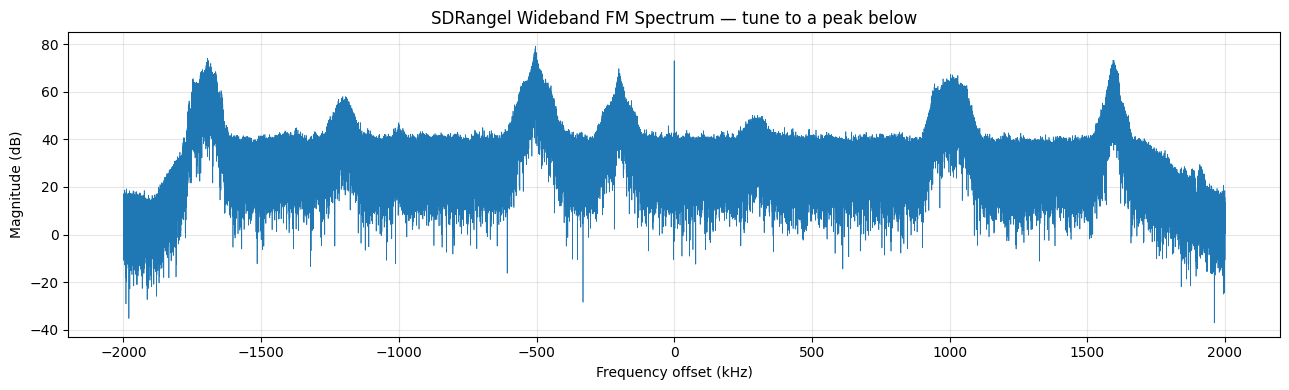

Loaded. Run the tuner cell below.


In [14]:
import zipfile, io
from scipy.io import wavfile
from src.signal.channel_select import channel_select

BFM_FS = 4_000_000.0
with zipfile.ZipFile('../data/bfm.zip') as z:
    with z.open('bfm.2021-12-16T14_23_16_147.wav') as f:
        _, raw_bfm = wavfile.read(io.BytesIO(f.read()))

bfm_i = raw_bfm[:, 0].astype(np.float32) / 32768.0
bfm_q = raw_bfm[:, 1].astype(np.float32) / 32768.0
bfm_iq = (bfm_i + 1j * bfm_q).astype(np.complex64)

# Wideband spectrum
seg = bfm_iq[:int(BFM_FS * 0.1)]
n = seg.size
freqs_wide = np.fft.fftshift(np.fft.fftfreq(n, 1/BFM_FS))
mag_wide = 20 * np.log10(np.maximum(np.abs(np.fft.fftshift(np.fft.fft(seg))), 1e-12))
plt.figure(figsize=(13, 4))
plt.plot(freqs_wide / 1000, mag_wide, linewidth=0.5)
plt.title('SDRangel Wideband FM Spectrum — tune to a peak below')
plt.xlabel('Frequency offset (kHz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Loaded. Run the tuner cell below.')

In [ ]:
def plot_fm_channel(center_khz):
    # ── Signal Processing ────────────────────────────────────────────────────
    chan = channel_select(bfm_iq, BFM_FS, center_hz=center_khz*1000.0, bandwidth_hz=200_000.0, decim_factor=20)
    audio = fm_demod(chan.iq, chan.sample_rate, lpf_cutoff_hz=15000.0, de_emphasis_tau=50e-6)
    n = chan.iq.size
    freqs = np.fft.fftshift(np.fft.fftfreq(n, 1/chan.sample_rate))
    mag = 20 * np.log10(np.maximum(np.abs(np.fft.fftshift(np.fft.fft(chan.iq))), 1e-12))
    t = np.arange(audio.size) / chan.sample_rate

    # ── Visualization ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(freqs / 1000, mag, linewidth=0.8)
    axes[0].set_title(f'Channel Spectrum  (offset {center_khz:+d} kHz)')
    axes[0].set_xlabel('kHz (relative to channel center)')
    axes[0].set_ylabel('Magnitude (dB)')
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(t, audio, linewidth=0.4)
    axes[1].set_title('Demodulated FM Audio')
    axes[1].set_xlabel('Time (s)')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(
    plot_fm_channel,
    center_khz=widgets.IntSlider(value=-518, min=-1900, max=1900, step=100,
        description='Center offset (kHz)',
        style={'description_width':'initial'},
        layout=widgets.Layout(width='600px')),
);

interactive(children=(IntSlider(value=-518, description='Center offset (kHz)', layout=Layout(width='600px'), m…

In [12]:
# FM Audio player — set CENTER_KHZ to match slider above, then run
from scipy.signal import resample_poly, firwin, lfilter
from math import gcd

CENTER_KHZ = -518
chan_play = channel_select(bfm_iq, BFM_FS, center_hz=CENTER_KHZ*1000.0, bandwidth_hz=200_000.0, decim_factor=20)
audio_fm = fm_demod(chan_play.iq, chan_play.sample_rate, lpf_cutoff_hz=15000.0, de_emphasis_tau=50e-6)
taps = firwin(129, 15000 / (chan_play.sample_rate / 2))
audio_fm = lfilter(taps, 1.0, audio_fm)
audio_fm = audio_fm / (np.max(np.abs(audio_fm)) + 1e-12)
audio_50k = resample_poly(audio_fm, 1, 4)
g = gcd(50000, 44100)
audio_play = resample_poly(audio_50k, 44100 // g, 50000 // g)
Audio(audio_play, rate=44100)